In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Problem statement ##

Analyze sales data from January 2022 to February 2026 to identify top-performing products, seasonal trends, and underperforming regional markets. This insight will optimize inventory allocation and marketing spend to maximize profitability for the remainder of 2026.

In [2]:
!pip install openpyxl


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
sheets=pd.read_excel("D:\Regional Sales Dataset.xlsx", sheet_name = None)

In [4]:
#assigen dataframe to each sheet

df_sales = sheets['Sales Orders']
df_customers = sheets['Customers']
df_Regions = sheets['Regions']
df_stateRegion = sheets['State Regions']
df_products = sheets['Products']
df_budget = sheets['2017 Budgets']

In [5]:
df_sales.shape

(64104, 12)

In [6]:
#to print all the data
print('df_sales_shape',(df_sales.shape))
print('df_sales_shape',(df_customers.shape))
print('df_sales_shape',(df_Regions.shape))
print('df_sales_shape',(df_stateRegion.shape))
print('df_sales_shape',(df_products.shape))
print('df_sales_shape',(df_budget.shape))

df_sales_shape (64104, 12)
df_sales_shape (175, 2)
df_sales_shape (994, 15)
df_sales_shape (49, 3)
df_sales_shape (30, 2)
df_sales_shape (30, 2)


In [7]:
df_stateRegion.head(3)

,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South


In [8]:
#changing the header form the first colum
new_header = df_stateRegion.iloc[0]
df_stateRegion.columns = new_header
df_stateRegion =df_stateRegion[1:].reset_index(drop = True)

df_stateRegion.head(5)


,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [9]:
df_sales.isnull().sum()

OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64

In [10]:
df_customers.isnull().sum()

Customer Index    0
Customer Names    0
dtype: int64

In [11]:
df_Regions.isnull().sum()

id               0
name             0
county           0
state_code       0
state            0
type             0
latitude         0
longitude        0
area_code        0
population       0
households       0
median_income    0
land_area        0
water_area       0
time_zone        0
dtype: int64

In [12]:
df_stateRegion.isnull().sum()

0
State Code    0
State         0
Region        0
dtype: int64

In [13]:
df_products.isnull().sum()

Index           0
Product Name    0
dtype: int64

In [14]:
df_budget.isnull().sum()

Product Name    0
2017 Budgets    0
dtype: int64

In [16]:
### Data cleaning and Wrangling ##

In [17]:
#merge with customers

df = df_sales.merge(
    df_customers,
    how='left',
    left_on = 'Customer Name Index',
    right_on = 'Customer Index'
)
df.head(3)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp


In [18]:
#merge with Product

df = df.merge(
    df_products,
    how='left',
    left_on = 'Product Description Index',
    right_on = 'Index'
)
df.head(3)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26


In [19]:
#merge with regions

df = df.merge(
    df_Regions,
    how='left',
    left_on = 'Delivery Region Index',
    right_on = 'id'
)
df.head(3)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles


In [20]:
#merge with stateregions

df = df.merge(
    df_stateRegion[['State Code','Region']],
    how='left',
    left_on = 'state_code',
    right_on = 'State Code'
)
df.head(3)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West


In [21]:
#merge with budgets

df = df.merge(
    df_budget,
    how='left',
    on = 'Product Name'
)
df.head(3)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270


In [22]:
df.to_csv('Files.csv',index=False)

In [23]:
#State Code,id,Index,Customer Index
#Clean up redundent colums
drop_columns= ['Customer Index','Index','id','State Code']
df=df.drop(columns=drop_columns,errors='ignore')
df.head(3)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270


In [24]:
#convert the colum headder into lower case
df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [25]:
#getting rid of unuse full columns
cols_to_keep = ['ordernumber', 'orderdate', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name', 'channel','county', 'state', 'state_code','latitude',
       'longitude','region','2017 budgets']


In [26]:
df=df[cols_to_keep]
df.head(2)

,ordernumber,orderdate,order quantity,unit price,line total,total unit cost,customer names,product name,channel,county,state,state_code,latitude,longitude,region,2017 budgets
0,SO - 000225,2014-01-01,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Wholesale,Chatham County,Georgia,GA,32.08354,-81.09983,South,964940.231
1,SO - 0003378,2014-01-01,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,Distributor,Johnson County,Indiana,IN,39.61366,-86.10665,Midwest,2067108.120


In [30]:
# Convert to datetime (if not already done)
df['orderdate'] = pd.to_datetime(df['orderdate'])

# Shift all dates forward by 8 years
df['orderdate'] = df['orderdate'] - pd.DateOffset(years=8)

print(df['orderdate'])

0       2022-01-01
1       2022-01-01
2       2022-01-01
3       2022-01-01
4       2022-01-01
           ...    
64099   2026-02-28
64100   2026-02-28
64101   2026-02-28
64102   2026-02-28
64103   2026-02-28
Name: orderdate, Length: 64104, dtype: datetime64[ns]


In [31]:
df.head()

,ordernumber,orderdate,order quantity,unit price,line total,total unit cost,customer names,product name,channel,county,state,state_code,latitude,longitude,region,2017 budgets
0,SO - 000225,2022-01-01,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Wholesale,Chatham County,Georgia,GA,32.08354,-81.09983,South,964940.231
1,SO - 0003378,2022-01-01,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,Distributor,Johnson County,Indiana,IN,39.61366,-86.10665,Midwest,2067108.120
2,SO - 0005126,2022-01-01,6,978.2,5869.2,684.740,Amerisourc Corp,Product 26,Wholesale,Alameda County,California,CA,37.66243,-121.87468,West,5685138.270
3,SO - 0005614,2022-01-01,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Product 7,Export,Monroe County,Indiana,IN,39.16533,-86.52639,Midwest,889737.555
4,SO - 0005781,2022-01-01,8,2291.4,18331.2,1260.270,Deseret Group,Product 8,Wholesale,Hartford County,Connecticut,CT,41.77524,-72.52443,Northeast,1085037.329


In [39]:
#rename colums
df =  df.rename(columns={'ordernumber':'order_number',
'orderdate':'order_date',
'order quantity':'order_quantity',
'unit price':'unit_price',
'line total':'Revenue',
'total unit cost':'total_unit_cost',
'customer names':'customer_name',
'product name':'product_name',
'2017 budgets':'budget'
})
df.head(1)

,order_number,order_date,order_quantity,unit_price,Revenue,total_unit_cost,customer_name,product_name,channel,county,state,state_code,latitude,longitude,region,budget
0,SO - 000225,2022-01-01,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Wholesale,Chatham County,Georgia,GA,32.08354,-81.09983,South,NaN


In [40]:
#blank out the budget
df.loc[df['order_date'].dt.year != 2017,'budget']=pd.NA

#line total is reveune
df[['order_date','product_name','Revenue','budget']].head(2)


,order_date,product_name,Revenue,budget
0,2022-01-01,Product 27,14994.6,NaN
1,2022-01-01,Product 20,25868.7,NaN


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   order_quantity   64104 non-null  int64         
 3   unit_price       64104 non-null  float64       
 4   Revenue          64104 non-null  float64       
 5   total_unit_cost  64104 non-null  float64       
 6   customer_name    64104 non-null  object        
 7   product_name     64104 non-null  object        
 8   channel          64104 non-null  object        
 9   county           64104 non-null  object        
 10  state            64104 non-null  object        
 11  state_code       64104 non-null  object        
 12  latitude         64104 non-null  float64       
 13  longitude        64104 non-null  float64       
 14  region           64104 non-null  objec

In [42]:
#filter dataset to include only record 2017
df_2017=df[df['order_date'].dt.year == 2025]

In [43]:
df.isnull().sum()

order_number           0
order_date             0
order_quantity         0
unit_price             0
Revenue                0
total_unit_cost        0
customer_name          0
product_name           0
channel                0
county                 0
state                  0
state_code             0
latitude               0
longitude              0
region                 0
budget             64104
dtype: int64

In [44]:
df_2017.head(3)

,order_number,order_date,order_quantity,unit_price,Revenue,total_unit_cost,customer_name,product_name,channel,county,state,state_code,latitude,longitude,region,budget
46363,SO - 0002544,2025-01-01,6,1239.5,7437.0,1028.785,NCS Group,Product 30,Wholesale,Hudson County,New Jersey,NJ,40.77955,-74.02375,Northeast,NaN
46364,SO - 0006431,2025-01-01,5,1829.1,9145.5,1207.206,Epic Group,Product 13,Wholesale,Mesa County,Colorado,CO,39.06387,-108.55065,West,NaN
46365,SO - 0007491,2025-01-01,9,2412.0,21708.0,1664.280,State Ltd,Product 15,Wholesale,Los Angeles County,California,CA,33.96168,-118.35313,West,NaN


In [45]:
#eda Feature Engineering

In [46]:
df.head(5)

,order_number,order_date,order_quantity,unit_price,Revenue,total_unit_cost,customer_name,product_name,channel,county,state,state_code,latitude,longitude,region,budget
0,SO - 000225,2022-01-01,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Wholesale,Chatham County,Georgia,GA,32.08354,-81.09983,South,NaN
1,SO - 0003378,2022-01-01,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,Distributor,Johnson County,Indiana,IN,39.61366,-86.10665,Midwest,NaN
2,SO - 0005126,2022-01-01,6,978.2,5869.2,684.740,Amerisourc Corp,Product 26,Wholesale,Alameda County,California,CA,37.66243,-121.87468,West,NaN
3,SO - 0005614,2022-01-01,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Product 7,Export,Monroe County,Indiana,IN,39.16533,-86.52639,Midwest,NaN
4,SO - 0005781,2022-01-01,8,2291.4,18331.2,1260.270,Deseret Group,Product 8,Wholesale,Hartford County,Connecticut,CT,41.77524,-72.52443,Northeast,NaN


In [47]:
df['total_cost']=df['order_quantity']*df['total_unit_cost']

In [48]:
df['profit']=df['Revenue']-df['total_cost']
df['profit_margin_pct']=df['profit']/df['Revenue']*100

In [49]:
df.head(5)

,order_number,order_date,order_quantity,unit_price,Revenue,total_unit_cost,customer_name,product_name,channel,county,state,state_code,latitude,longitude,region,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2022-01-01,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Wholesale,Chatham County,Georgia,GA,32.08354,-81.09983,South,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2022-01-01,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,Distributor,Johnson County,Indiana,IN,39.61366,-86.10665,Midwest,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2022-01-01,6,978.2,5869.2,684.740,Amerisourc Corp,Product 26,Wholesale,Alameda County,California,CA,37.66243,-121.87468,West,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2022-01-01,7,2338.3,16368.1,1028.852,Colgate-Pa Group,Product 7,Export,Monroe County,Indiana,IN,39.16533,-86.52639,Midwest,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2022-01-01,8,2291.4,18331.2,1260.270,Deseret Group,Product 8,Wholesale,Hartford County,Connecticut,CT,41.77524,-72.52443,Northeast,NaN,10082.160,8249.040,45.0


In [50]:
## EDA ##

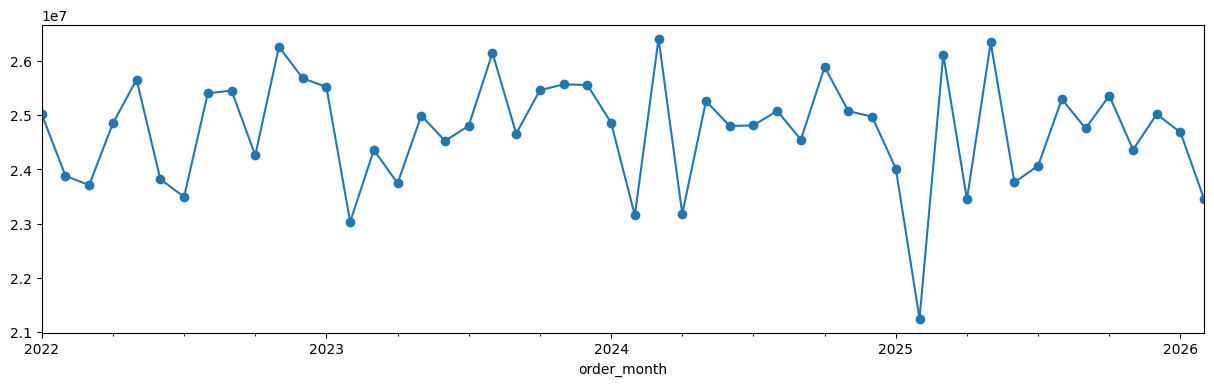

In [51]:
df['order_month']=df['order_date'].dt.to_period('M')

monthly_sales = df.groupby('order_month')['Revenue'].sum()

plt.figure(figsize=(15,4))

ax = monthly_sales.plot(kind='line',marker='o')


In [55]:
# Make sure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Remove January 2018 and February 2018 records
df_new= df[~((df['order_date'].dt.year == 2026) & 
          (df['order_date'].dt.month.isin([1, 2])))]

In [56]:
# Create an explicit copy to avoid SettingWithCopyWarning
df_new = df_new.copy()

# Convert order_date to datetime
df_new['order_date'] = pd.to_datetime(df_new['order_date'])

# Extract month name
df_new['month_name'] = df_new['order_date'].dt.month_name()

# Set proper chronological order for months
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df_new['month_name'] = pd.Categorical(
    df_new['month_name'], 
    categories=month_order, 
    ordered=True
)

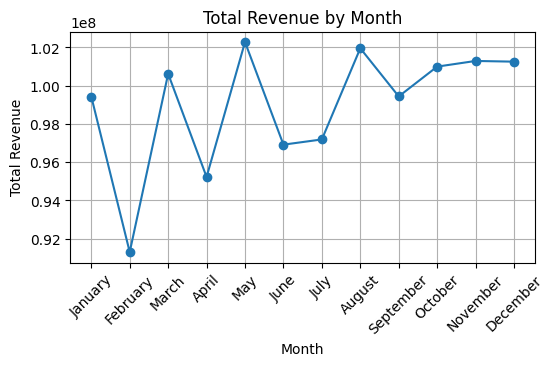

In [57]:
# Calculate total revenue by month
monthly_sales = df_new.groupby('month_name',observed = True)['Revenue'].sum()

# Draw the line chart
plt.figure(figsize=(6, 3))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#Revenue is not consistent throughout the year.

It shows ups and downs, with a clear dip in February and strong performance in May and August. The last quarter (Oct–Dec) is quite stable and high.

product_name
Product 26    112454990.9
Product 25    105715762.4
Product 13     75190019.7
Product 14     72516666.1
Product 5      68032711.2
Name: Revenue, dtype: float64


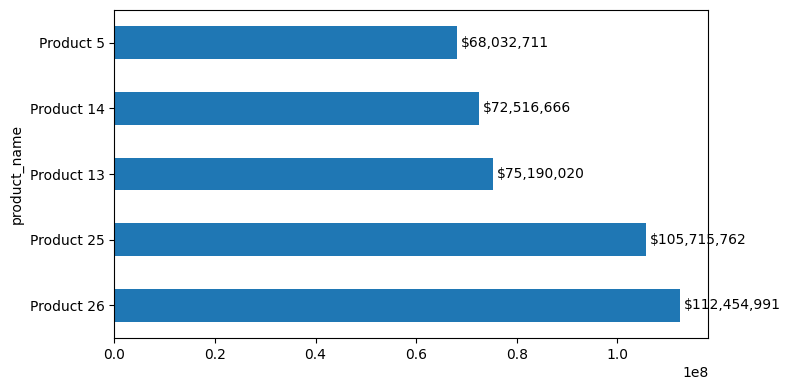

In [58]:
#top 5 product by revenue
top_5_product = df_new.groupby('product_name')['Revenue'].sum().sort_values(ascending=False).head(5)
print(top_5_product)

plt.figure(figsize=(8,4))

ax=top_5_product.plot(kind='barh')
ax.bar_label(ax.containers[0],fmt='${:,.0f}',padding=3)

plt.tight_layout()
plt.show()

Product 26 is the highest revenue-generating product.
Product 25 is the second best, very close to Product 26.
There is a clear gap after the top 2 products — Product 13, 14, and 5 earn significantly less.
The top 2 products (26 & 25) together contribute much more than the other three combined.

product_name
Product 26    112454990.9
Product 25    105715762.4
Product 13     75190019.7
Product 14     72516666.1
Product 5      68032711.2
Name: Revenue, dtype: float64


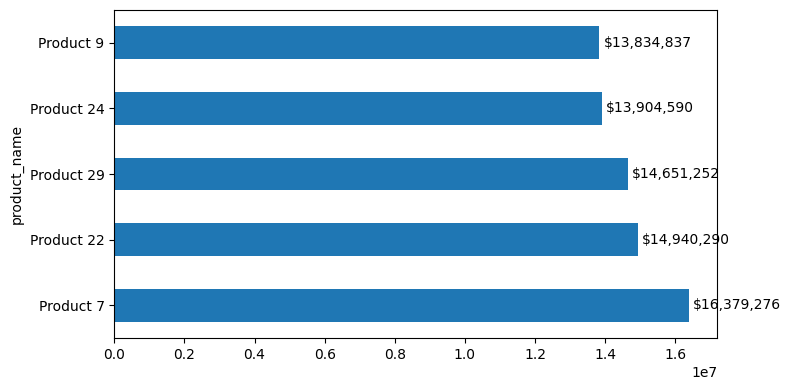

In [59]:
#top 5 product by revenue
Bottom_5_product = df_new.groupby('product_name')['Revenue'].sum().sort_values(ascending=False).tail(5)
print(top_5_product)

plt.figure(figsize=(8,4))

ax=Bottom_5_product.plot(kind='barh')
ax.bar_label(ax.containers[0],fmt='${:,.0f}',padding=3)

plt.tight_layout()
plt.show()

Product 9 has the lowest revenue among all products.
The bottom 5 products are quite close to each other in revenue.
Even the highest among these (Product 7) earns only about $16.4 million, which is much lower compared to the top products (which were above $100 million).

channel
Distributor    372247598.1
Export         173373253.5
Wholesale      642218094.9
Name: Revenue, dtype: float64


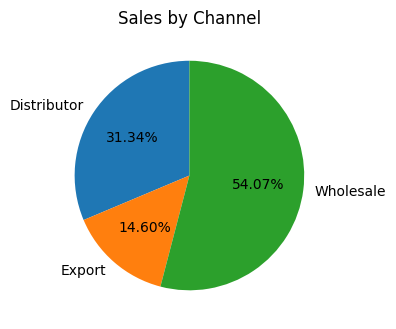

In [60]:
##Sales by channel

channel_sales= df_new.groupby('channel')['Revenue'].sum()
print(channel_sales)

plt.figure(figsize=(4,4))

channel_sales.plot(
    kind='pie',
    autopct='%.2f%%',
    startangle=90
)

plt.ylabel('')
plt.title('Sales by Channel')

plt.tight_layout()
plt.show()

Wholesale is the dominant channel, contributing more than half of the total sales (54%).
Distributor is the second largest channel with about 31% share.
Export has the smallest contribution at around 15%.

Overall: Most of the company’s sales come from the Wholesale channel.

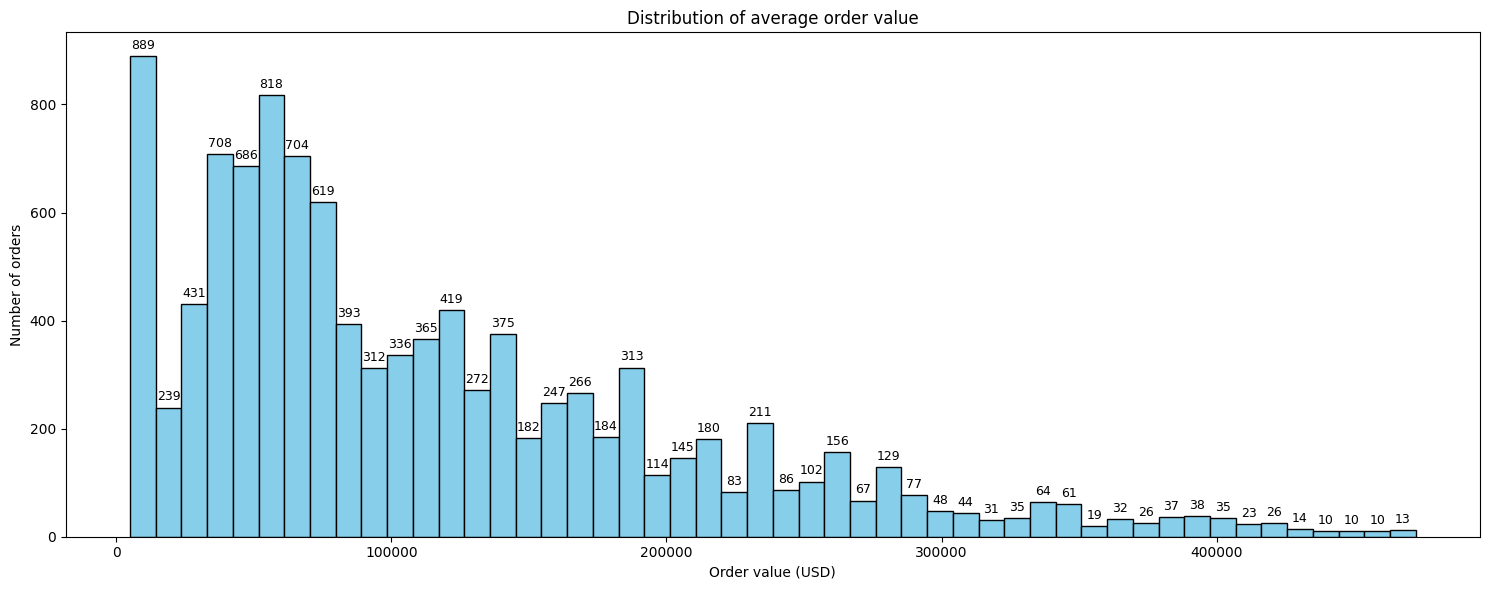

In [61]:
#Average Order Value(AOV) Distribution

aov = df.groupby('order_number')['Revenue'].sum()

plt.figure(figsize=(15, 6))

ax=aov.plot(
    kind='hist',
    bins=50,
    color='skyblue',
    edgecolor= 'black'
)
ax.bar_label(ax.containers[0],padding = 3,fontsize=9)
plt.title('Distribution of average order value')
plt.xlabel('Order value (USD)')
plt.ylabel('Number of orders')

plt.tight_layout()

plt.show()

The majority of customers place small to medium-sized orders.

High-value orders exist but are much less frequent. This is a typical right-skewed distribution (many small orders, few large ones).

In [62]:
aov = df.groupby('order_number')['Revenue'].sum().mean()
print(aov)

115684.09762261325


In [63]:
df['Revenue'].sum()

1235968899.0

<Figure size 1200x600 with 0 Axes>

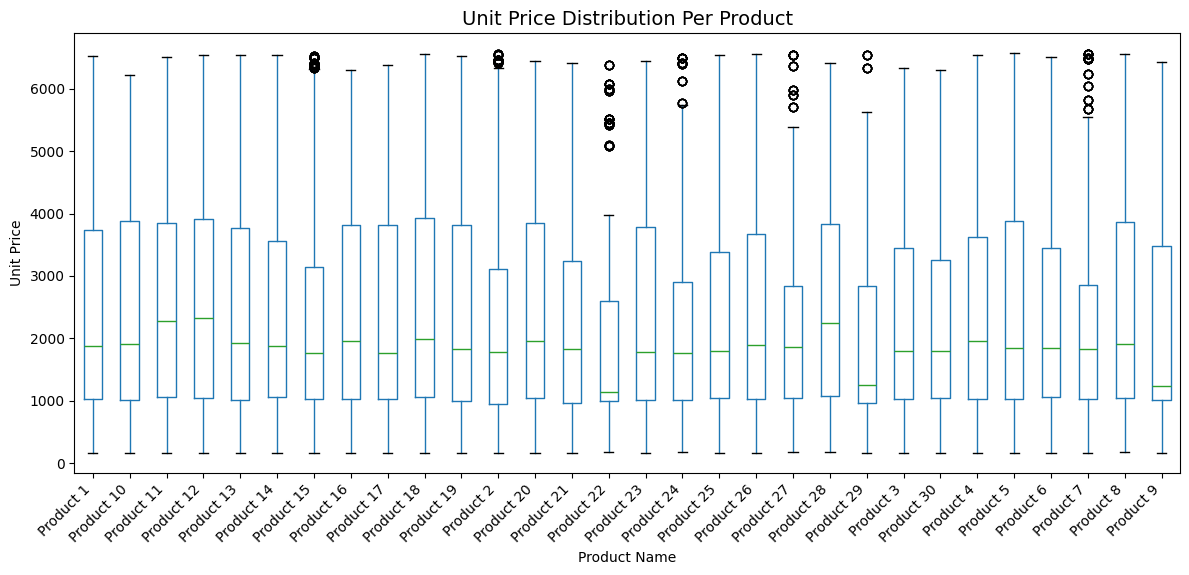

In [64]:
#unit price distribution per product 
#unit_price_distribution = df.groupby('product_name')['unit_price'].sum(){this code is wronge beacuse it calculate the revenue }
plt.figure(figsize=(12, 6))

# 1. Create the figure and ax canvas
fig, ax = plt.subplots(figsize=(12, 6))

# 2. Use native Pandas to draw the boxplot directly onto the 'ax' canvas
df_new.boxplot(
    column='unit_price', 
    by='product_name', 
    ax=ax,
    grid=False # Turns off the default background grid lines
)

# 3. Clean up the titles and labels using the 'ax' object
ax.set_title('Unit Price Distribution Per Product', fontsize=14)
ax.set_xlabel('Product Name')
ax.set_ylabel('Unit Price')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# 4. Remove the default automatic subtitle that Pandas generates
plt.suptitle('')

plt.tight_layout()
plt.show()


Most products have a similar average (median) unit price, but prices vary a lot within each product. A few products have some extremely high-priced orders (outliers).

In [65]:
#top 5 states by revenue and order count
State_rev_ord= df.groupby('state').agg(
    total_revenue=('Revenue','sum'),
    order_count=('order_number','nunique')
).sort_values(by='total_revenue',ascending=False)
print(State_rev_ord)

                      total_revenue  order_count
state                                           
California              228785436.0         7613
Illinois                111050965.7         4607
Florida                  90204679.5         3836
Texas                    84011903.0         3582
New York                 55534960.0         2543
Indiana                  54601690.2         2544
New Jersey               46830956.5         2162
Connecticut              44251228.7         2073
Michigan                 39025315.8         1889
Massachusetts            35011942.1         1643
Washington               28915853.3         1439
Colorado                 27683776.9         1343
Ohio                     25214518.7         1220
Minnesota                24520928.0         1244
North Carolina           24123068.6         1208
Arizona                  23388246.1         1188
Virginia                 21385026.5         1071
Georgia                  20726912.3         1045
Maryland            

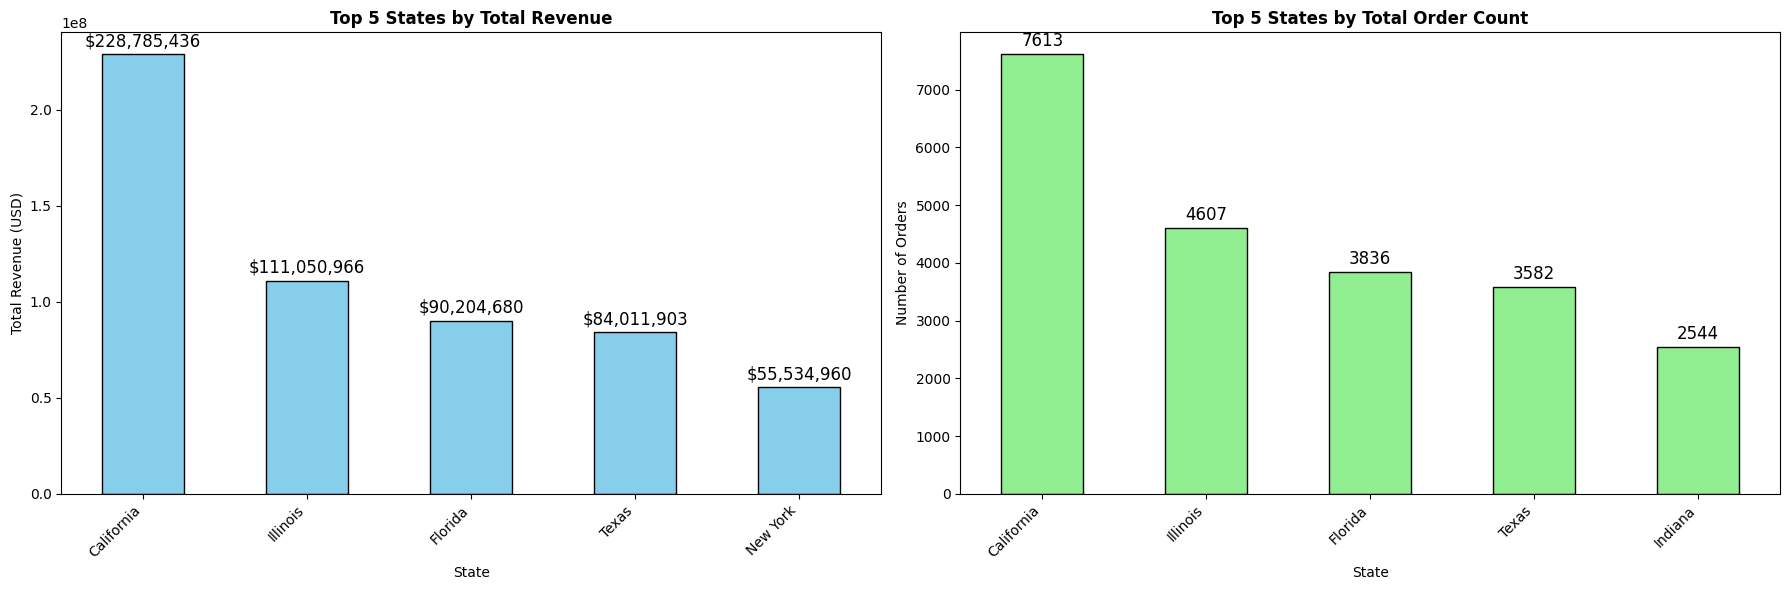

In [66]:

# 1. Aggregate revenue and unique order count per state
state_performance = df.groupby('state').agg(
    total_revenue=('Revenue', 'sum'),
    order_count=('order_number', 'nunique')
)

# 2. Extract the Top 5 for each metric independently
top_5_revenue = state_performance['total_revenue'].nlargest(5)
top_5_orders = state_performance['order_count'].nlargest(5)

# 3. Create a side-by-side dashboard layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Chart 1: Top 5 States by Revenue
top_5_revenue.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax1)
ax1.bar_label(ax1.containers[0], padding=3, fmt='${:,.0f}', fontsize=12)
ax1.set_title('Top 5 States by Total Revenue', fontsize=12, fontweight='bold')
ax1.set_xlabel('State')
ax1.set_ylabel('Total Revenue (USD)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Chart 2: Top 5 States by Order Count
top_5_orders.plot(kind='bar', color='lightgreen', edgecolor='black', ax=ax2)
ax2.bar_label(ax2.containers[0], padding=3, fmt='%d', fontsize=12)
ax2.set_title('Top 5 States by Total Order Count', fontsize=12, fontweight='bold')
ax2.set_xlabel('State')
ax2.set_ylabel('Number of Orders')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


California dominates the business. Most of the top-performing states (California, Illinois, Florida, Texas) are strong in both revenue and order volume.

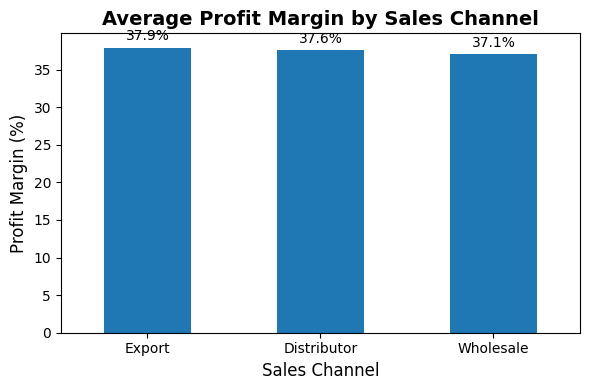

In [67]:
#avg profit margin by channel
profit_margin_channel = df.groupby('channel')['profit_margin_pct'].mean().sort_values(ascending=False)

fig,ax=plt.subplots(figsize=(6,4))
profit_margin_channel.plot(kind='bar')
ax.bar_label(ax.containers[0],padding=3,fmt='%.1f%%',fontsize=10)

ax.set_title('Average Profit Margin by Sales Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales Channel', fontsize=12)
ax.set_ylabel('Profit Margin (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0) 

plt.tight_layout()
plt.show()


All three channels have very similar profit margins (around 37–38%).
Export has a slightly higher profit margin than the other two.
Wholesale has the lowest margin among the three, but the difference is very small (less than 1%).

Overall: Profitability is almost the same across all sales channels. There is no major difference in profit margin between Export, Distributor, and Wholesale.

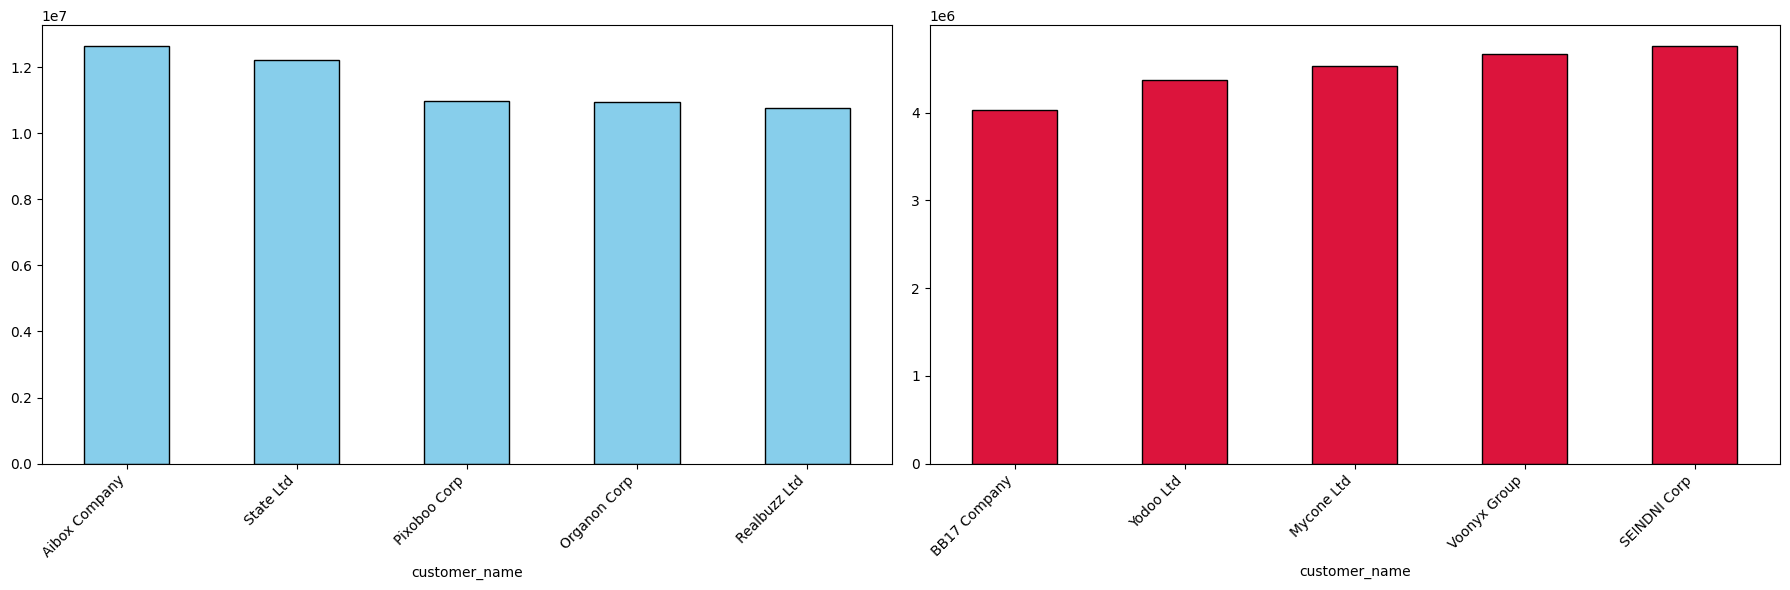

In [68]:
#top and bottom 5 customer by reveune
customer_rev=df.groupby('customer_name')['Revenue'].sum()

top5customer=customer_rev.nlargest(5)
bottom5customer=customer_rev.nsmallest(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

top5customer.plot(kind='bar', color='skyblue', edgecolor='black',ax=ax1)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

bottom5customer.plot(kind='bar', color='crimson', edgecolor='black',ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

#The top customers generate significantly higher revenue (around $11–12.5 million) compared  to  the bottom customers (around $4–4.8 million).
Aibox Company is the highest revenue-generating customer.
The gap between top and bottom customers is quite large — top customers contribute nearly 3 times more revenue than the bottom ones.

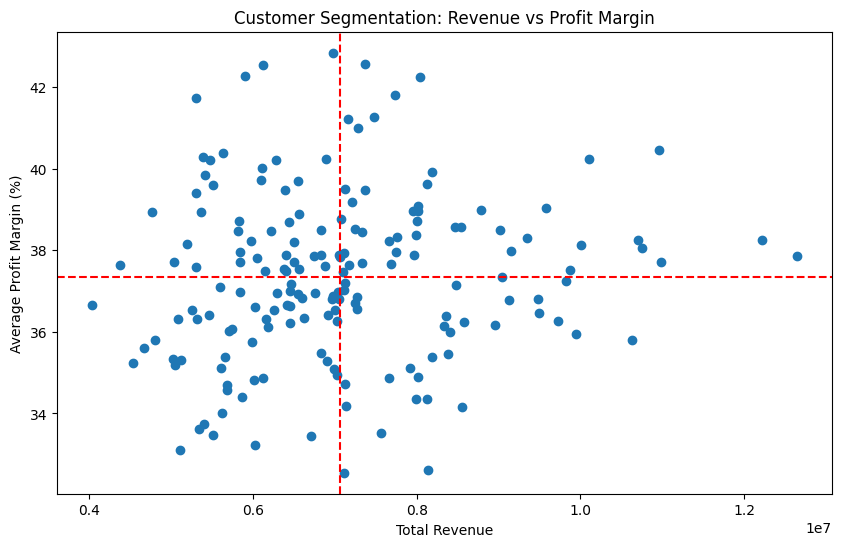

In [69]:
import matplotlib.pyplot as plt

# 1. Group by customer to calculate total revenue and average margin
customer_seg = df.groupby('customer_name').agg(
    total_revenue=('Revenue', 'sum'),
    avg_margin=('profit_margin_pct', 'mean')
)

# 2. Draw a basic scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(customer_seg['total_revenue'], customer_seg['avg_margin'])

# =========================================================================
# HIGHLIGHTED ADDITION: Draws crosshairs to instantly build the 4 quadrants
# =========================================================================
plt.axvline(customer_seg['total_revenue'].mean(), color='red', linestyle='--')
plt.axhline(customer_seg['avg_margin'].mean(), color='red', linestyle='--')
# =========================================================================

# 3. Basic Labels
plt.title('Customer Segmentation: Revenue vs Profit Margin')
plt.xlabel('Total Revenue')
plt.ylabel('Average Profit Margin (%)')

plt.show()



Most customers are clustered in the middle (around $5–8 million revenue and 36–40% profit margin).
A few customers stand out with very high revenue (above $10 million).
Profit margins mostly range between 34% to 42%.
There is no strong clear pattern that higher revenue always means higher or lower profit margin — customers are quite spread out.

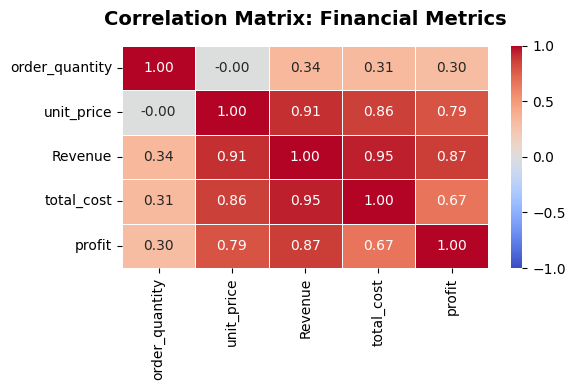

In [70]:
#correlation Heat map with selected numarical columns
#quantitu,unitprice,revenue,total cost,profit

# 1. Create a subset dataframe with only your selected columns
# (Make sure to match the exact uppercase/lowercase spelling of your columns)
selected_cols = ['order_quantity', 'unit_price', 'Revenue', 'total_cost', 'profit']
corr_matrix = df[selected_cols].corr()

# 2. Setup the canvas layout
fig, ax = plt.subplots(figsize=(6, 4))

# 3. Draw the warning-free correlation heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,             # Shows the exact correlation number inside each square
    cmap='coolwarm',        # Red means positive connection, Blue means negative connection
    fmt='.2f',              # Rounds numbers to 2 decimal places
    linewidths=0.5,         # Adds a clean white border between squares
    vmin=-1, vmax=1,        # Sets standard correlation bounds
    ax=ax
)

# Chart styling
ax.set_title('Correlation Matrix: Financial Metrics', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()


Revenue, unit price, total cost, and profit are all strongly connected to each other.
Order quantity has a very weak relationship with revenue, cost, and profit.
The strongest relationship is between Revenue and total_cost (0.95).

Overall: Price and cost drive revenue and profit much more than the number of units ordered.

In [71]:
df_new.columns

Index(['order_number', 'order_date', 'order_quantity', 'unit_price', 'Revenue',
       'total_unit_cost', 'customer_name', 'product_name', 'channel', 'county',
       'state', 'state_code', 'latitude', 'longitude', 'region', 'budget',
       'total_cost', 'profit', 'profit_margin_pct', 'order_month',
       'month_name'],
      dtype='object')

In [72]:
df_new.head(2)

,order_number,order_date,order_quantity,unit_price,Revenue,total_unit_cost,customer_name,product_name,channel,county,...,state_code,latitude,longitude,region,budget,total_cost,profit,profit_margin_pct,order_month,month_name
0,SO - 000225,2022-01-01,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,Product 27,Wholesale,Chatham County,...,GA,32.08354,-81.09983,South,NaN,10946.058,4048.542,27.0,2022-01,January
1,SO - 0003378,2022-01-01,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,Product 20,Distributor,Johnson County,...,IN,39.61366,-86.10665,Midwest,NaN,13969.098,11899.602,46.0,2022-01,January
